In [16]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.ensemble import AdaBoostClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


In [17]:
df = pd.read_csv("telco_customer_churn.csv")

In [18]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [19]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [20]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [21]:
df = df.drop(columns=['customerID'])

In [22]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [23]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

In [24]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [25]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [26]:
le_gender = LabelEncoder()
df['gender'] = le_gender.fit_transform(df['gender'])

le_partner = LabelEncoder()
df['Partner'] = le_partner.fit_transform(df['Partner'])

le_dependents = LabelEncoder()
df['Dependents'] = le_dependents.fit_transform(df['Dependents'])

le_phone_service = LabelEncoder()
df['PhoneService'] = le_phone_service.fit_transform(df['PhoneService'])

le_multiple_lines = LabelEncoder()
df['MultipleLines'] = le_multiple_lines.fit_transform(df['MultipleLines'])

le_internet_service = LabelEncoder()
df['InternetService'] = le_internet_service.fit_transform(df['InternetService'])

le_online_security = LabelEncoder()
df['OnlineSecurity'] = le_online_security.fit_transform(df['OnlineSecurity'])

le_online_backup = LabelEncoder()
df['OnlineBackup'] = le_online_backup.fit_transform(df['OnlineBackup'])

le_device_protection = LabelEncoder()
df['DeviceProtection'] = le_device_protection.fit_transform(df['DeviceProtection'])

le_tech_support = LabelEncoder()
df['TechSupport'] = le_tech_support.fit_transform(df['TechSupport'])

le_streaming_tv = LabelEncoder()
df['StreamingTV'] = le_streaming_tv.fit_transform(df['StreamingTV'])

le_streaming_movies = LabelEncoder()
df['StreamingMovies'] = le_streaming_movies.fit_transform(df['StreamingMovies'])

le_contract = LabelEncoder()
df['Contract'] = le_contract.fit_transform(df['Contract'])

le_paperless_billing = LabelEncoder()
df['PaperlessBilling'] = le_paperless_billing.fit_transform(df['PaperlessBilling'])

le_payment_method = LabelEncoder()
df['PaymentMethod'] = le_payment_method.fit_transform(df['PaymentMethod'])

le_churn = LabelEncoder()
df['Churn'] = le_churn.fit_transform(df['Churn'])

In [27]:
X = df.drop(columns=['Churn'])
y = df['Churn']

In [28]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.2
)

In [29]:
model = AdaBoostClassifier(random_state= 42)
model.fit(X_train, y_train)

c:\Users\Srinith Samala\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(random_state=42)

In [30]:
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Train Score:", model.score(X_train, y_train))
print("Test Score:", model.score(X_test, y_test))

[[935 101]
 [176 197]]
0.8034066713981547
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.66      0.53      0.59       373

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

Train Score: 0.8090166844160455
Test Score: 0.8034066713981547


c:\Users\Srinith Samala\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Srinith Samala\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Srinith Samala\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Srinith Samala\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The

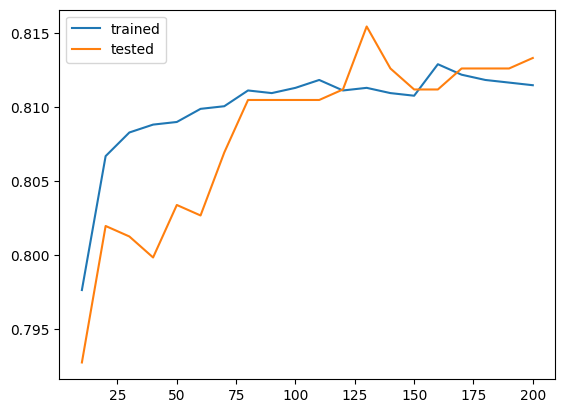

In [33]:
train_scores , test_scores = [],[]
n_ranges = range(10,201,10)
for n in n_ranges:
    m = AdaBoostClassifier(n_estimators=n,random_state=42)
    m.fit(X_train,y_train)
    train_scores.append(m.score(X_train,y_train))
    test_scores.append(m.score(X_test,y_test))

plt.plot(n_ranges,train_scores ,label = "trained")
plt.plot(n_ranges,test_scores ,label = "tested")
plt.legend()
plt.show()

In [34]:
best_index = np.argmax(test_scores)
best_n = list(n_ranges)[best_index]
print('best bias:',best_n)

model = AdaBoostClassifier(n_estimators=best_n,random_state=42)
model.fit(X_train,y_train)

best bias: 130


c:\Users\Srinith Samala\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(n_estimators=130, random_state=42)

In [35]:
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Train Score:", model.score(X_train, y_train))
print("Test Score:", model.score(X_test, y_test))

[[936 100]
 [160 213]]
0.815471965933286
              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1036
           1       0.68      0.57      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409

Train Score: 0.811324103656372
Test Score: 0.815471965933286


In [36]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(importance_df)

             Feature  Importance
18      TotalCharges    0.376923
17    MonthlyCharges    0.223077
4             tenure    0.200000
14          Contract    0.061538
16     PaymentMethod    0.030769
8     OnlineSecurity    0.023077
7    InternetService    0.015385
11       TechSupport    0.015385
5       PhoneService    0.007692
0             gender    0.007692
1      SeniorCitizen    0.007692
15  PaperlessBilling    0.007692
13   StreamingMovies    0.007692
6      MultipleLines    0.007692
9       OnlineBackup    0.007692
2            Partner    0.000000
3         Dependents    0.000000
10  DeviceProtection    0.000000
12       StreamingTV    0.000000
